In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

np.random.seed(42)
data = pd.DataFrame({
    "Group": np.repeat(["Control", "Treatment"], 50),
    "Score": np.concatenate([np.random.normal(100, 15, 50), np.random.normal(110, 15, 50)]),
    "Hours_Studied": np.random.uniform(1, 10, 100),
    "Category": np.random.choice(["A", "B", "C"], 100)
})

In [3]:
data

,Group,Score,Hours_Studied,Category
0,Control,107.450712,4.756699,B
1,Control,97.926035,2.998970,A
2,Control,109.715328,2.078788,B
3,Control,122.845448,4.038537,A
4,Control,96.487699,9.486187,C
...,...,...,...,...
95,Treatment,88.047276,3.195907,C
96,Treatment,114.441804,9.757095,A
97,Treatment,113.915829,4.537880,A
98,Treatment,110.076702,9.028419,A


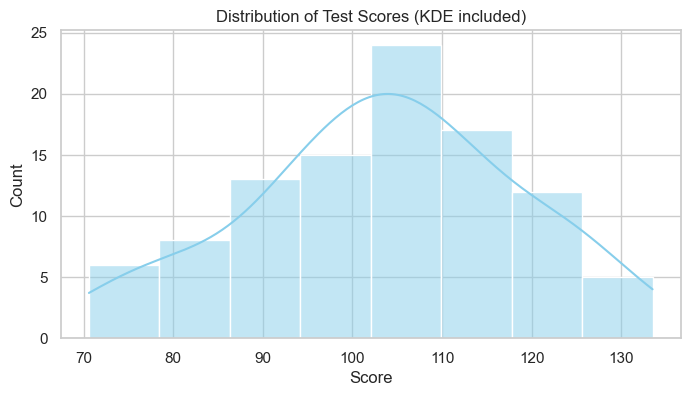

In [4]:
plt.figure(figsize=(8, 4))
sns.histplot(data=data, x = "Score", kde=True, color='skyblue')
plt.title("Distribution of Test Scores (KDE included)")
plt.show()

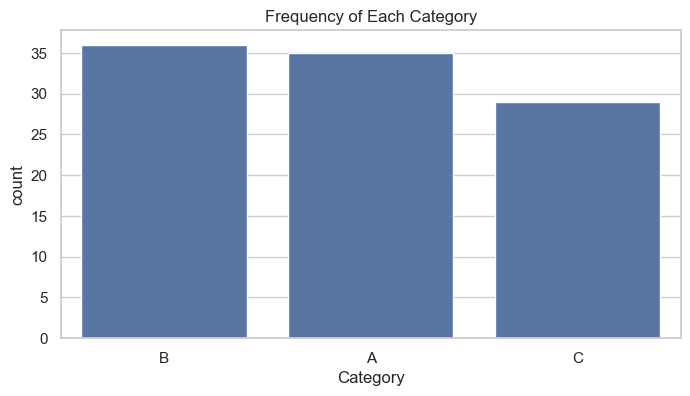

In [5]:
plt.figure(figsize=(8, 4))
sns.countplot(data=data, x="Category")
plt.title("Frequency of Each Category")
plt.show()

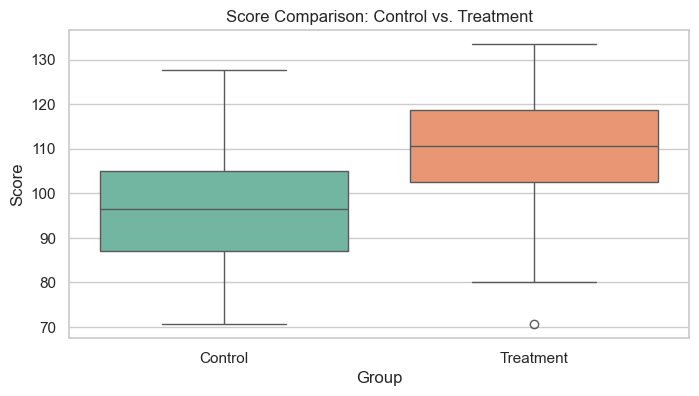

In [6]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=data, x="Group", y="Score", hue="Group", palette="Set2")
plt.title("Score Comparison: Control vs. Treatment")
plt.show()

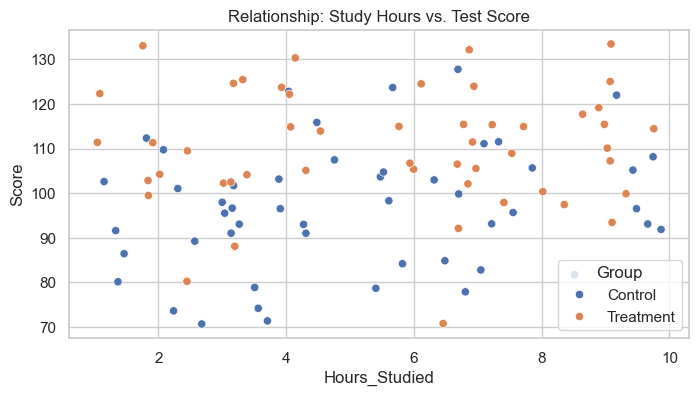

In [7]:
plt.figure(figsize=(8, 4))
sns.scatterplot(data=data, x = "Hours_Studied", y = "Score", hue = "Group")
plt.title("Relationship: Study Hours vs. Test Score")
plt.show()

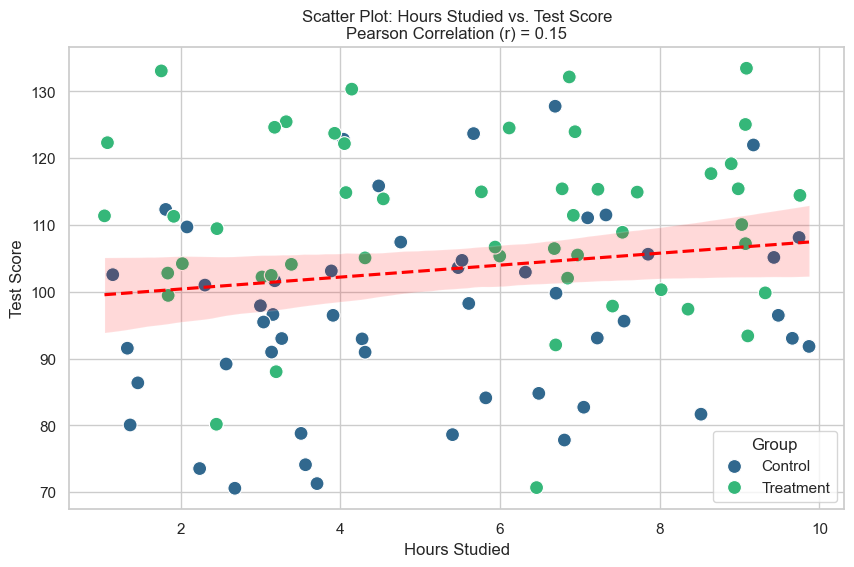

In [8]:
corr_value = data["Hours_Studied"].corr(data["Score"])

plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x="Hours_Studied", y="Score", hue="Group", palette="viridis", s=100)

sns.regplot(data=data, x="Hours_Studied", y="Score", scatter=False, color='red', line_kws={"ls":"--"})

plt.title(f'Scatter Plot: Hours Studied vs. Test Score\nPearson Correlation (r) = {corr_value:.2f}')
plt.xlabel("Hours Studied")
plt.ylabel("Test Score")

plt.show()


In [11]:
five_num = data.groupby("Group").describe()[["Score", "Hours_Studied"]].loc[:,(slice(None), ['min', '25%', '50%', '75%', 'max'])]


print(five_num)

               Score                                                  \
                 min         25%         50%         75%         max   
Group                                                                  
Control    70.604948   87.085313   96.487823  105.044133  127.784173   
Treatment  70.703823  102.558330  110.691204  118.806111  133.469655   

          Hours_Studied                                          
                    min       25%       50%       75%       max  
Group                                                            
Control        1.149290  3.143068  4.618659  6.988554  9.870854  
Treatment      1.045554  3.227299  6.286319  7.672217  9.757095  
